# Yelp Metric Comparisons

Load the saved metric rows and compare models across threshold choices.

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120


In [10]:
DRIVE_METRICS_PATH = Path("/content/drive/MyDrive/yelp_metrics.csv")
LOCAL_METRICS_PATH = Path("script/yelp/yelp_metrics.csv") if Path("script/yelp").exists() else Path("yelp_metrics.csv")

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

METRICS_PATH = DRIVE_METRICS_PATH if DRIVE_METRICS_PATH.exists() else LOCAL_METRICS_PATH
if not METRICS_PATH.exists():
    raise FileNotFoundError(f"Could not find metrics CSV at {DRIVE_METRICS_PATH} or {LOCAL_METRICS_PATH}")

metrics = pd.read_csv(METRICS_PATH)
print(f"Loaded {len(metrics):,} rows from {METRICS_PATH}")
metrics.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 75 rows from /content/drive/MyDrive/yelp_metrics.csv


,rowname,threhold_type,threshold_value,f_1,balanced_accuracy,roc-aoc,precision_pos,recall_pos
0,S_gm_weighted_linear,0.5,0.500,0.393500,0.625063,0.869794,0.801418,0.260769
1,S_gm_weighted_linear,best_balanced_accuracy,0.143,0.498237,0.787634,0.869794,0.358714,0.815385
2,S_gm_weighted_linear,best_f1,0.254,0.556217,0.757171,0.869794,0.510611,0.610769
3,S_gm_weighted_nn,0.5,0.500,0.644244,0.753239,0.929763,0.838471,0.523077
4,S_gm_weighted_nn,best_balanced_accuracy,0.137,0.602121,0.845308,0.929763,0.465713,0.851538


In [11]:
rename_map = {
    "roc-aoc": "roc_auc",
    "f_1": "f1",
    "threhold_type": "threshold_type",
}
plot_df = metrics.rename(columns=rename_map).copy()

required = [
    "rowname",
    "threshold_type",
    "threshold_value",
    "f1",
    "balanced_accuracy",
    "roc_auc",
    "precision_pos",
    "recall_pos",
]
missing = [column for column in required if column not in plot_df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

for column in required[2:]:
    plot_df[column] = pd.to_numeric(plot_df[column], errors="coerce")

plot_df = plot_df.dropna(subset=["rowname", "threshold_type", "f1", "balanced_accuracy", "roc_auc"])
plot_df = plot_df.drop_duplicates(subset=["rowname", "threshold_type"], keep="last")

threshold_order = ["0.5", "best_balanced_accuracy", "best_f1"]
plot_df["threshold_type"] = pd.Categorical(plot_df["threshold_type"], categories=threshold_order, ordered=True)
plot_df = plot_df.sort_values(["rowname", "threshold_type"])

plot_df.head()


,rowname,threshold_type,threshold_value,f1,balanced_accuracy,roc_auc,precision_pos,recall_pos
60,N_graph_LR_graph_feat,0.5,0.500000,0.604679,0.819590,0.91642,0.499749,0.765385
61,N_graph_LR_graph_feat,best_balanced_accuracy,-0.042245,0.563213,0.835681,0.91642,0.415508,0.873846
62,N_graph_LR_graph_feat,best_f1,0.882000,0.602368,0.787900,0.91642,0.550254,0.665385
63,N_graph_LR_graph_logit_only,0.5,0.500000,0.562732,0.835686,0.91642,0.414812,0.874615
64,N_graph_LR_graph_logit_only,best_balanced_accuracy,0.502000,0.563352,0.835745,0.91642,0.415660,0.873846


In [12]:
best_f1_df = plot_df[plot_df["threshold_type"].eq("best_f1")].sort_values("f1", ascending=False)
best_balacc_df = plot_df[plot_df["threshold_type"].eq("best_balanced_accuracy")].sort_values("balanced_accuracy", ascending=False)

display(best_f1_df[["rowname", "threshold_value", "f1", "balanced_accuracy", "roc_auc", "precision_pos", "recall_pos"]].head(20))
display(best_balacc_df[["rowname", "threshold_value", "f1", "balanced_accuracy", "roc_auc", "precision_pos", "recall_pos"]].head(20))


,rowname,threshold_value,f1,balanced_accuracy,roc_auc,precision_pos,recall_pos
11,S_hm_weighted_nn,0.339,0.710863,0.822414,0.940625,0.739203,0.684615
47,T_yelp_Relation_GCN_MLP_skip,0.732,0.699522,0.828621,0.938871,0.687139,0.712360
5,S_gm_weighted_nn,0.360,0.687111,0.800853,0.929763,0.744834,0.637692
17,S_unweigh_neural,0.333,0.666403,0.799712,0.920550,0.685366,0.648462
8,S_hm_weighted_linear,0.269,0.646915,0.816312,0.930245,0.591460,0.713846
56,T_yelp_Relation_GAT_MLP_skip,0.768,0.610568,0.764131,0.893516,0.639344,0.584270
62,N_graph_LR_graph_feat,0.882,0.602368,0.787900,0.916420,0.550254,0.665385
71,N_graph_LR_graph_logit_plus_graph_laplacian,0.719,0.602166,0.787126,0.916420,0.551504,0.663077
65,N_graph_LR_graph_logit_only,0.720,0.602166,0.787126,0.916420,0.551504,0.663077
74,N_graph_LR_graph_logit_plus_EB_plus_graph_lapl...,0.719,0.602166,0.787126,0.916429,0.551504,0.663077


,rowname,threshold_value,f1,balanced_accuracy,roc_auc,precision_pos,recall_pos
46,T_yelp_Relation_GCN_MLP_skip,0.447000,0.649490,0.862760,0.938871,0.522076,0.859176
10,S_hm_weighted_nn,0.141000,0.634778,0.862508,0.940625,0.500444,0.867692
7,S_hm_weighted_linear,0.176000,0.628588,0.846739,0.930245,0.507569,0.825385
4,S_gm_weighted_nn,0.137000,0.602121,0.845308,0.929763,0.465713,0.851538
16,S_unweigh_neural,0.151000,0.602072,0.837689,0.920550,0.473360,0.826923
67,N_graph_LR_graph_logit_plus_EB,0.502000,0.563352,0.835745,0.916429,0.415660,0.873846
73,N_graph_LR_graph_logit_plus_EB_plus_graph_lapl...,0.501000,0.563352,0.835745,0.916429,0.415660,0.873846
70,N_graph_LR_graph_logit_plus_graph_laplacian,0.501000,0.563352,0.835745,0.916420,0.415660,0.873846
64,N_graph_LR_graph_logit_only,0.502000,0.563352,0.835745,0.916420,0.415660,0.873846
61,N_graph_LR_graph_feat,-0.042245,0.563213,0.835681,0.916420,0.415508,0.873846


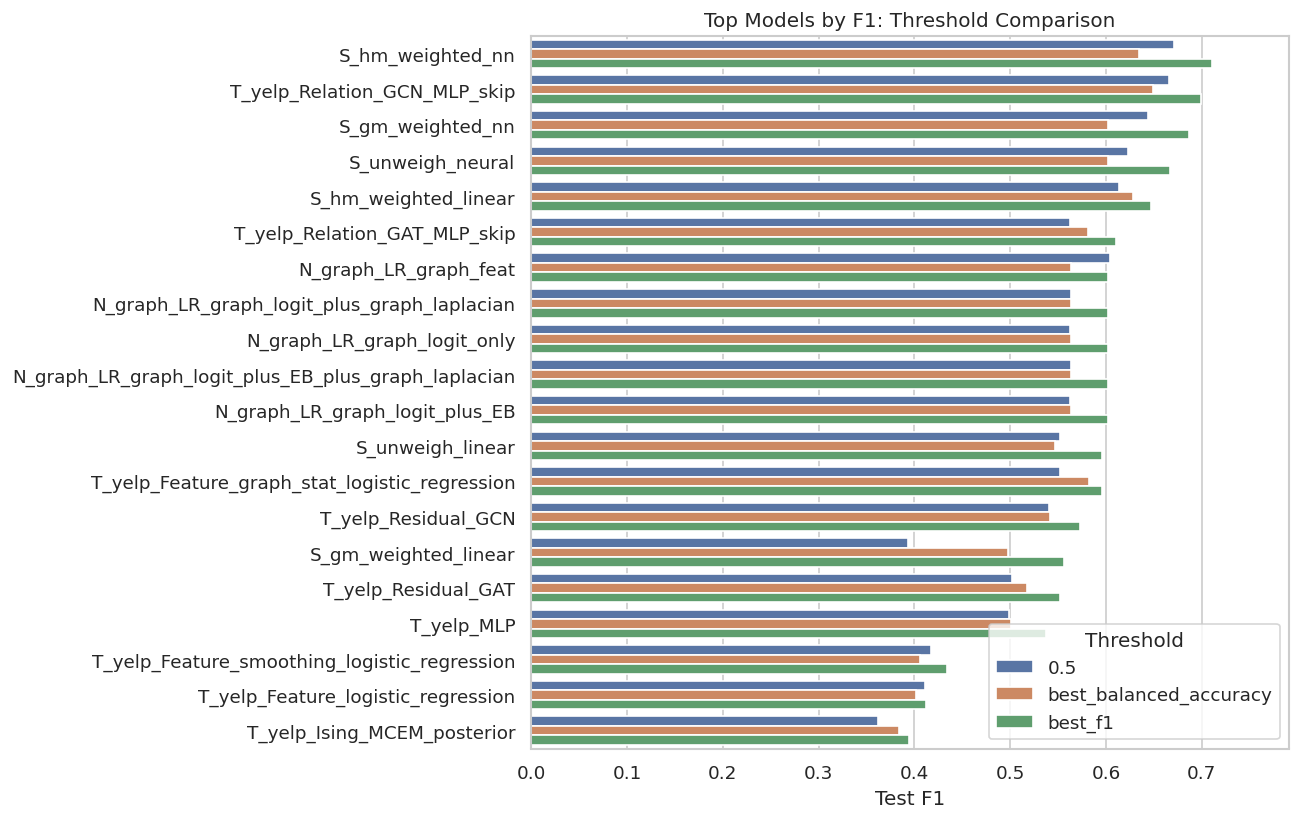

In [13]:
top_names = best_f1_df.head(20)["rowname"].tolist()
top_df = plot_df[plot_df["rowname"].isin(top_names)].copy()

fig, ax = plt.subplots(figsize=(11, max(5, 0.35 * len(top_names))))
sns.barplot(
    data=top_df,
    y="rowname",
    x="f1",
    hue="threshold_type",
    order=top_names,
    hue_order=threshold_order,
    ax=ax,
)
ax.set_title("Top Models by F1: Threshold Comparison")
ax.set_xlabel("Test F1")
ax.set_ylabel("")
ax.set_xlim(0, min(1, max(0.05, top_df["f1"].max() + 0.08)))
ax.legend(title="Threshold")
plt.tight_layout()
plt.show()


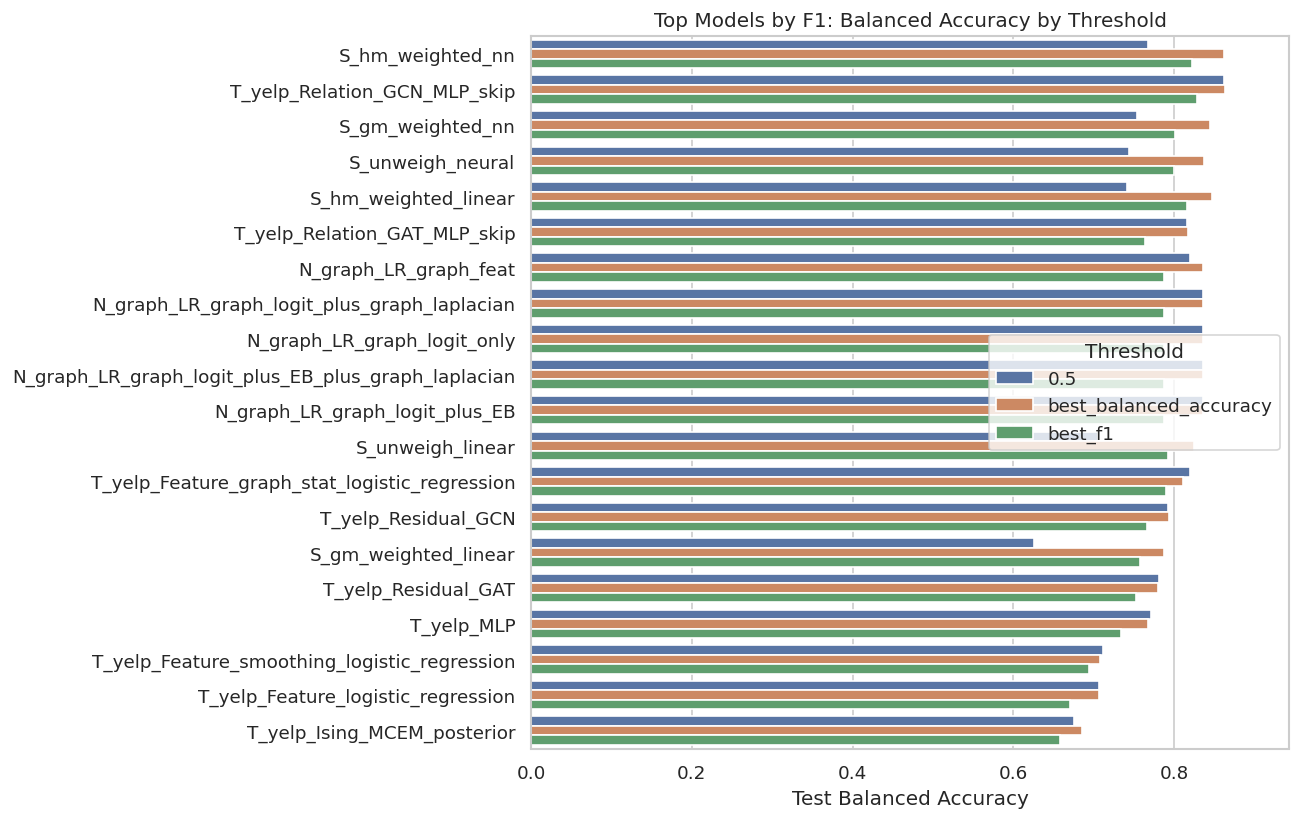

In [14]:
fig, ax = plt.subplots(figsize=(11, max(5, 0.35 * len(top_names))))
sns.barplot(
    data=top_df,
    y="rowname",
    x="balanced_accuracy",
    hue="threshold_type",
    order=top_names,
    hue_order=threshold_order,
    ax=ax,
)
ax.set_title("Top Models by F1: Balanced Accuracy by Threshold")
ax.set_xlabel("Test Balanced Accuracy")
ax.set_ylabel("")
ax.set_xlim(0, min(1, max(0.05, top_df["balanced_accuracy"].max() + 0.08)))
ax.legend(title="Threshold")
plt.tight_layout()
plt.show()


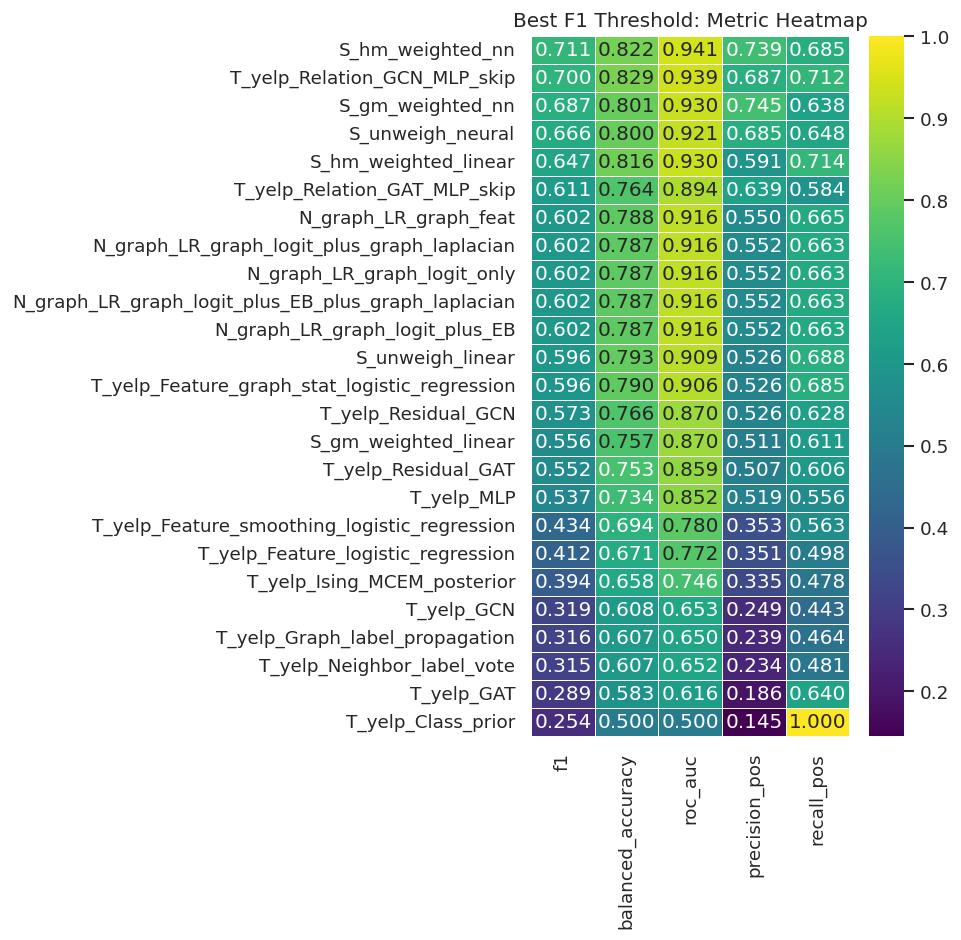

In [15]:
heat_df = best_f1_df.head(30).set_index("rowname")[[
    "f1",
    "balanced_accuracy",
    "roc_auc",
    "precision_pos",
    "recall_pos",
]]

fig, ax = plt.subplots(figsize=(8, max(5, 0.32 * len(heat_df))))
sns.heatmap(heat_df, annot=True, fmt=".3f", cmap="viridis", linewidths=0.4, ax=ax)
ax.set_title("Best F1 Threshold: Metric Heatmap")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


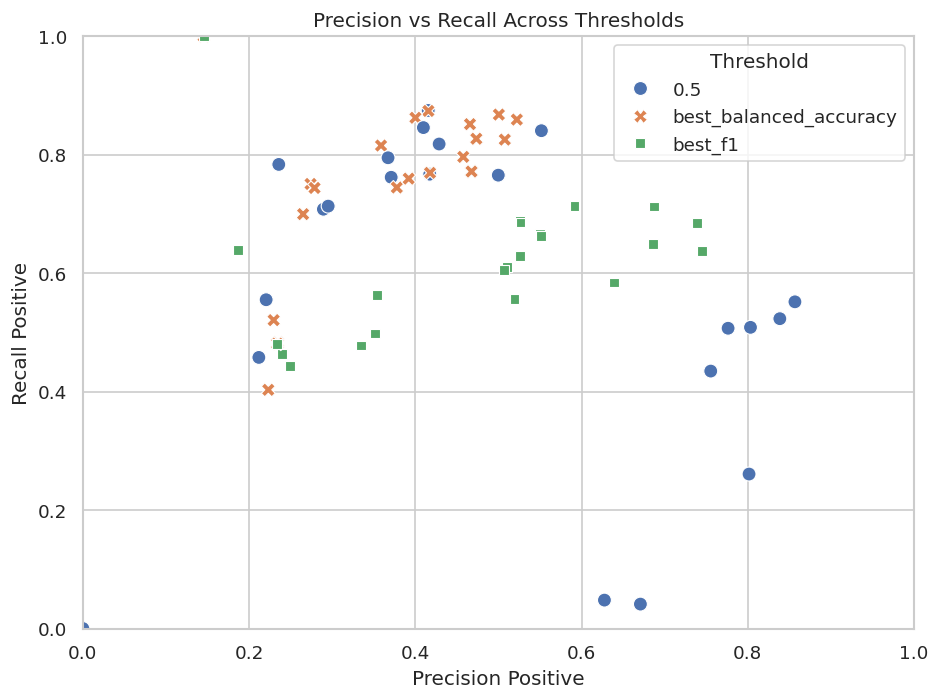

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x="precision_pos",
    y="recall_pos",
    hue="threshold_type",
    style="threshold_type",
    hue_order=threshold_order,
    ax=ax,
    s=70,
)
ax.set_title("Precision vs Recall Across Thresholds")
ax.set_xlabel("Precision Positive")
ax.set_ylabel("Recall Positive")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(title="Threshold")
plt.tight_layout()
plt.show()
